# NBA Salary vs Performance — Correlation & Value Analysis

This notebook builds on the merged salary + performance dataset and:

1. Engineers updated value / efficiency metrics  
2. Computes Pearson correlations between salary and multiple performance measures  
3. Evaluates player value using salary-adjusted metrics  
4. Produces visualizations (scatterplots, histograms, bar charts)  
5. Highlights the top 10 and bottom 10 players by value index

Update: the value metrics focus on **production normalized by minutes** and then scaled by salary.


In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

INPUT_PATH = "data/processed/final_dataset.csv"
PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

print("Using input file:", INPUT_PATH)
print("Plots will be saved to:", PLOTS_DIR)

Using input file: data/processed/final_dataset.csv
Plots will be saved to: plots


In [11]:
df = pd.read_csv("merged_salary_stats.csv")
print("Rows:", len(df))
df.head()

Rows: 679


,player,pos,age,tm,g,gs,mp,fg,fga,fg%,...,orb,drb,trb,ast,stl,blk,tov,pf,pts,salary
0,precious achiuwa,C,23,TOR,55,12,20.7,3.6,7.3,0.485,...,1.8,4.1,6.0,0.9,0.6,0.5,1.1,1.9,9.2,2840160.0
1,steven adams,C,29,MEM,42,42,27.0,3.7,6.3,0.597,...,5.1,6.5,11.5,2.3,0.9,1.1,1.9,2.3,8.6,17926829.0
2,bam adebayo,C,25,MIA,75,75,34.6,8.0,14.9,0.540,...,2.5,6.7,9.2,3.2,1.2,0.8,2.5,2.8,20.4,30351780.0
3,ochai agbaji,SG,22,UTA,59,22,20.5,2.8,6.5,0.427,...,0.7,1.3,2.1,1.1,0.3,0.3,0.7,1.7,7.9,3918360.0
4,santi aldama,PF,22,MEM,77,20,21.8,3.2,6.8,0.470,...,1.1,3.7,4.8,1.3,0.6,0.6,0.8,1.9,9.0,NaN


## Feature Engineering: Updated Value Metrics

We construct several metrics:

- `salary_million`: salary in millions of USD  
- `total_points`: season total points (PTS × games played)  
- `eff_raw`: composite box-score efficiency (PTS + TRB + AST + STL + BLK − TOV)  
- `eff_per_min`: efficiency per minute  
- `salary_per_point`: dollars per point scored  
- `value_index`: salary-adjusted efficiency (`eff_per_min` per salary million)  


In [12]:
df = df.copy()

df["salary"] = df["salary"].fillna(0)
df = df[df["salary"] > 0].copy()

df["salary_million"] = df["salary"] / 1_000_000

if "g" in df.columns:
    df["total_points"] = df["pts"] * df["g"]
else:
    df["total_points"] = df["pts"]

df["eff_raw"] = (
    df["pts"]
    + df["trb"]
    + df["ast"]
    + df.get("stl", 0)
    + df.get("blk", 0)
    - df.get("tov", 0)
)

df["eff_per_min"] = df["eff_raw"] / (df["mp"] + 1e-6)

df["salary_per_point"] = df["salary"] / (df["total_points"] + 1e-6)

df["value_index"] = df["eff_per_min"] / (df["salary_million"] + 1e-6)

df[["player", "salary", "salary_million", "pts", "eff_per_min",
    "salary_per_point", "value_index"]].head()

,player,salary,salary_million,pts,eff_per_min,salary_per_point,value_index
0,precious achiuwa,2840160.0,2.840160,9.2,0.777778,5612.964416,0.273850
1,steven adams,17926829.0,17.926829,8.6,0.833333,49631.309386,0.046485
2,bam adebayo,30351780.0,30.351780,20.4,0.933526,19837.764693,0.030757
3,ochai agbaji,3918360.0,3.918360,7.9,0.536585,8406.693824,0.136941
5,nickeil alexander-walker,5009633.0,5.009633,6.2,0.646667,13695.005430,0.129085


## Correlation Between Salary and Performance

We compute Pearson correlations between salary and key performance indicators:

- Salary vs PTS per game  
- Salary vs efficiency per minute (`eff_per_min`)  
- Salary vs shooting efficiency (FG% or eFG%)  


In [13]:
metrics = {}

metrics["salary_vs_pts"] = df["salary"].corr(df["pts"])

metrics["salary_vs_eff_per_min"] = df["salary"].corr(df["eff_per_min"])

shoot_col = "efg%" if "efg%" in df.columns else ("fg%" if "fg%" in df.columns else None)
if shoot_col is not None:
    metrics["salary_vs_shooting"] = df["salary"].corr(df[shoot_col])
else:
    metrics["salary_vs_shooting"] = np.nan

metrics

{'salary_vs_pts': 0.722943978301759,
 'salary_vs_eff_per_min': 0.4625638758648044,
 'salary_vs_shooting': 0.09777989783698735}

## Visualizations

We generate the following plots and save them into the `plots/` folder:

1. Scatterplot: Salary vs Points Per Game  
2. Scatterplot: Salary vs Efficiency per Minute  
3. Histogram: Salary distribution  
4. Bar chart: Average value index by team  
5. Bar chart: Top 10 players by value index  
6. Bar chart: Bottom 10 players by value index  


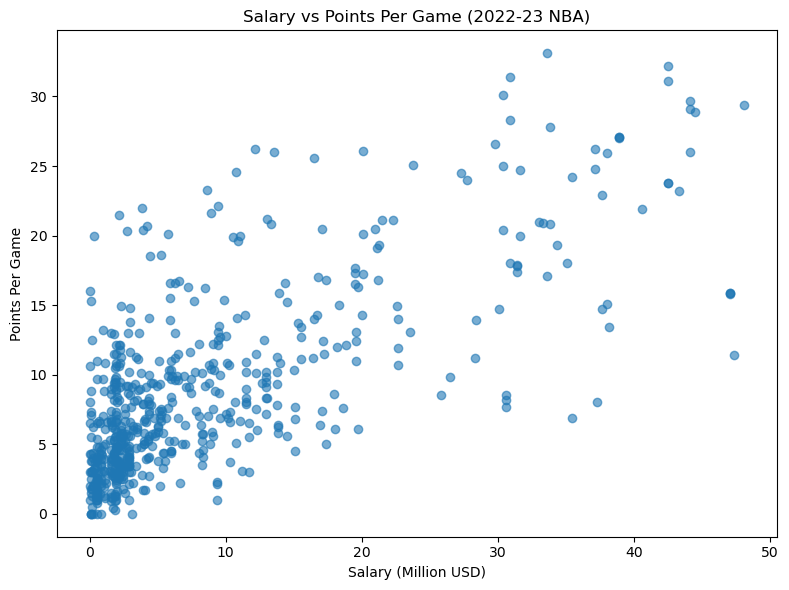

Saved: plots/salary_vs_pts.png


In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(df["salary_million"], df["pts"], alpha=0.6)
plt.xlabel("Salary (Million USD)")
plt.ylabel("Points Per Game")
plt.title("Salary vs Points Per Game (2022-23 NBA)")
plt.tight_layout()
path1 = os.path.join(PLOTS_DIR, "salary_vs_pts.png")
plt.savefig(path1, dpi=300)
plt.show()
print("Saved:", path1)

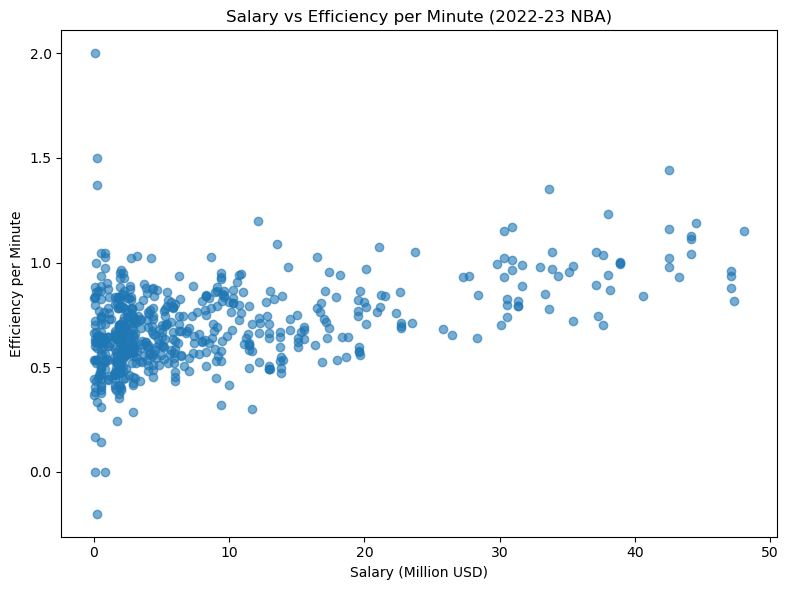

Saved: plots/salary_vs_eff_per_min.png


In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(df["salary_million"], df["eff_per_min"], alpha=0.6)
plt.xlabel("Salary (Million USD)")
plt.ylabel("Efficiency per Minute")
plt.title("Salary vs Efficiency per Minute (2022-23 NBA)")
plt.tight_layout()
path2 = os.path.join(PLOTS_DIR, "salary_vs_eff_per_min.png")
plt.savefig(path2, dpi=300)
plt.show()
print("Saved:", path2)

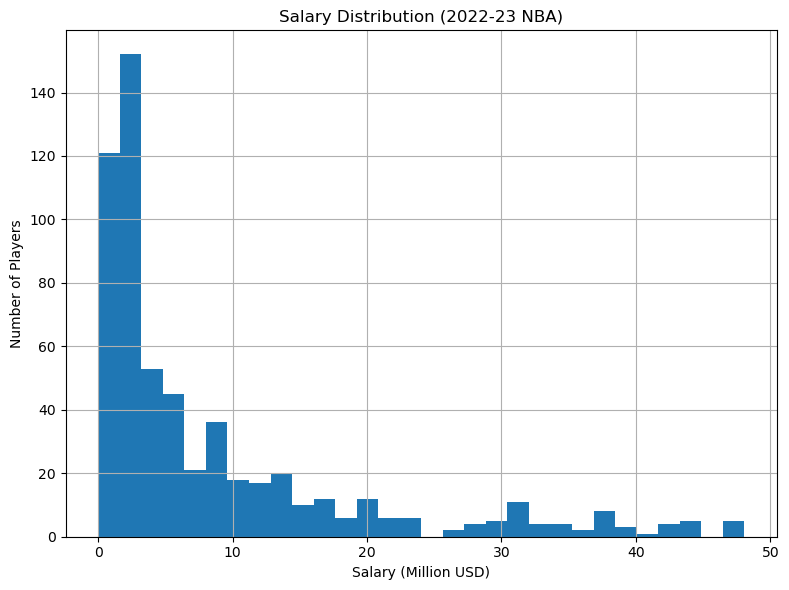

Saved: plots/salary_distribution.png


In [16]:
plt.figure(figsize=(8, 6))
df["salary_million"].hist(bins=30)
plt.xlabel("Salary (Million USD)")
plt.ylabel("Number of Players")
plt.title("Salary Distribution (2022-23 NBA)")
plt.tight_layout()
path3 = os.path.join(PLOTS_DIR, "salary_distribution.png")
plt.savefig(path3, dpi=300)
plt.show()
print("Saved:", path3)

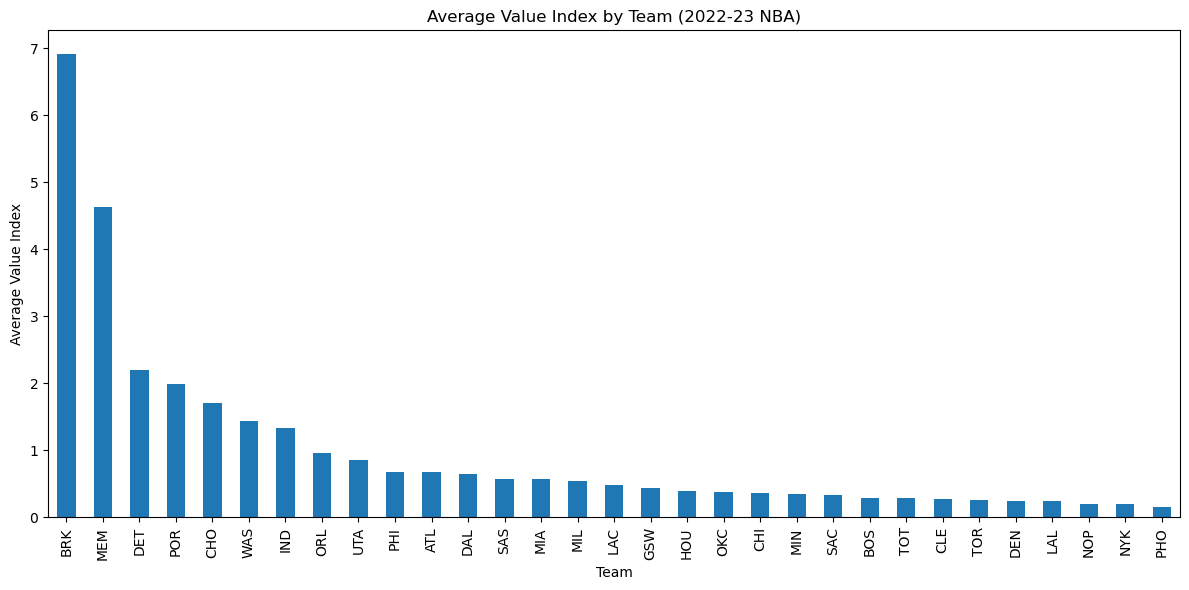

Saved: plots/team_average_value_index.png


In [17]:
if "tm" in df.columns:
    team_value = df.groupby("tm")["value_index"].mean().sort_values(ascending=False)

    plt.figure(figsize=(12, 6))
    team_value.plot(kind="bar")
    plt.ylabel("Average Value Index")
    plt.xlabel("Team")
    plt.title("Average Value Index by Team (2022-23 NBA)")
    plt.tight_layout()
    path4 = os.path.join(PLOTS_DIR, "team_average_value_index.png")
    plt.savefig(path4, dpi=300)
    plt.show()
    print("Saved:", path4)
else:
    print("Column 'tm' not found; skipping team-level plot.")

## Top 10 and Bottom 10 Players by Value Index

In [18]:
top10 = df.sort_values("value_index", ascending=False).head(10)
top10[["player", "tm", "salary_million", "pts", "eff_per_min", "value_index"]]

,player,tm,salary_million,pts,eff_per_min,value_index
222,raiquan gray,BRK,0.005849,16.0,0.828571,141.636138
211,jacob gilyard,MEM,0.005849,3.0,0.365854,62.539085
613,stanley umude,DET,0.058493,2.0,1.999999,34.191524
673,gabe york,IND,0.032171,8.0,0.663102,20.611139
568,kobi simmons,CHO,0.032795,1.0,0.535714,16.334742
558,jay scrubb,ORL,0.049719,6.5,0.633333,12.737999
424,justin minaya,POR,0.035096,4.3,0.443946,12.649120
657,jeenathan williams,POR,0.052644,10.6,0.622047,11.815884
555,jordan schakel,WAS,0.096514,1.5,0.833333,8.634234
75,jarrell brantley,UTA,0.105522,5.5,0.795918,7.542605


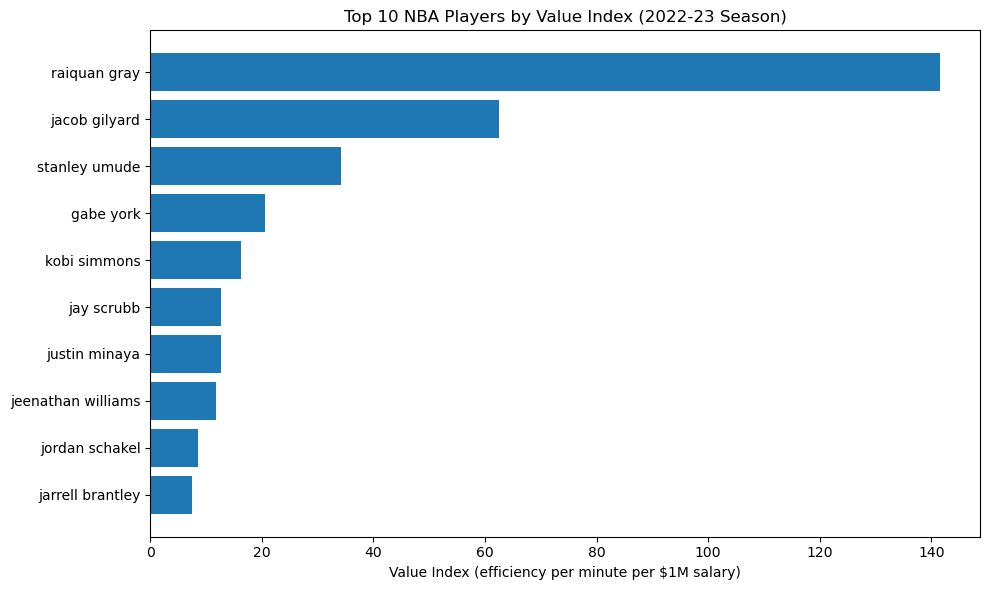

Saved: plots/top10_value_index.png


In [19]:
plt.figure(figsize=(10, 6))
plt.barh(top10["player"], top10["value_index"])
plt.xlabel("Value Index (efficiency per minute per $1M salary)")
plt.title("Top 10 NBA Players by Value Index (2022-23 Season)")
plt.gca().invert_yaxis()
plt.tight_layout()
path5 = os.path.join(PLOTS_DIR, "top10_value_index.png")
plt.savefig(path5, dpi=300)
plt.show()
print("Saved:", path5)

In [20]:
bottom10 = df.sort_values("value_index", ascending=True).head(10)
bottom10[["player", "tm", "salary_million", "pts", "eff_per_min", "value_index"]]

,player,tm,salary_million,pts,eff_per_min,value_index
652,alondes williams,BRK,0.254446,0.0,-0.200000,-0.786018
89,moses brown,BRK,0.824041,0.0,0.000000,0.000000
98,deonte burton,SAC,0.105522,0.0,0.000000,0.000000
630,john wall,LAC,47.345760,11.4,0.815315,0.017220
644,russell westbrook,LAC,47.080179,15.8,0.877483,0.018638
252,tobias harris,PHI,37.633050,14.7,0.702128,0.018657
642,russell westbrook,TOT,47.080179,15.9,0.934708,0.019854
628,kemba walker,DAL,37.281261,8.0,0.743750,0.019950
567,ben simmons,BRK,35.448672,6.9,0.718631,0.020272
643,russell westbrook,LAL,47.080179,15.9,0.958188,0.020352


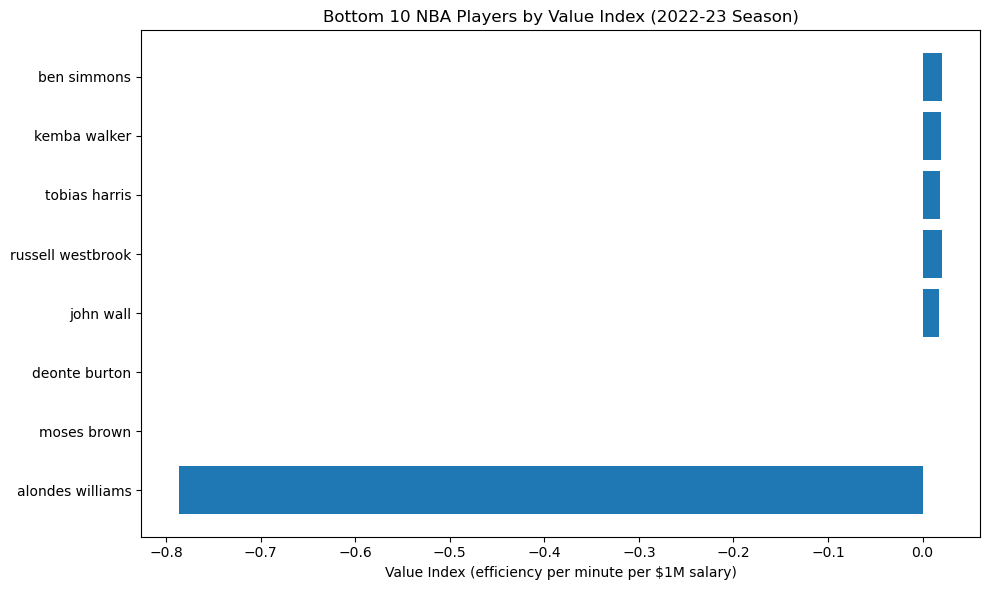

Saved: plots/bottom10_value_index.png


In [21]:
plt.figure(figsize=(10, 6))
plt.barh(bottom10["player"], bottom10["value_index"])
plt.xlabel("Value Index (efficiency per minute per $1M salary)")
plt.title("Bottom 10 NBA Players by Value Index (2022-23 Season)")
plt.tight_layout()
path6 = os.path.join(PLOTS_DIR, "bottom10_value_index.png")
plt.savefig(path6, dpi=300)
plt.show()
print("Saved:", path6)

                      player   tm  eff_per_min
613            stanley umude  DET     1.999999
653         donovan williams  ATL     1.499999
12     giannis antetokounmpo  MIL     1.442368
161             tyler dorsey  DAL     1.370370
184              joel embiid  PHI     1.352601
141            anthony davis  LAL     1.232353
435                ja morant  MEM     1.197492
306             lebron james  LAL     1.191549
209  shai gilgeous-alexander  OKC     1.169014
373           damian lillard  POR     1.162534


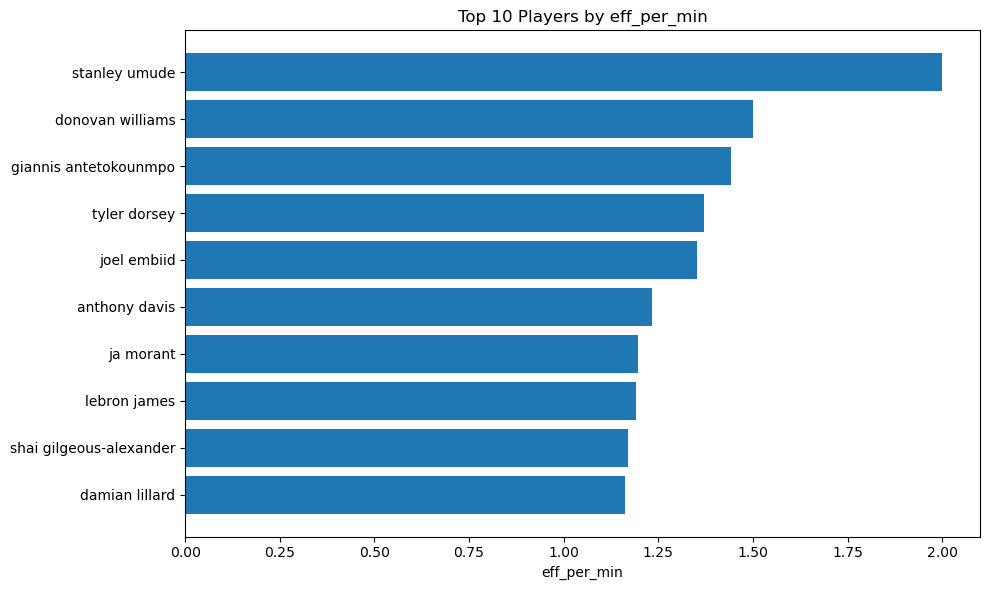

                player   tm  eff_per_min
652   alondes williams  BRK    -0.200000
89         moses brown  BRK     0.000000
98       deonte burton  SAC     0.000000
113  julian champagnie  PHI     0.142857
72      jamaree bouyea  WAS     0.166667
65     leandro bolmaro  UTA     0.244898
648       joe wieskamp  TOR     0.285714
225        danny green  MEM     0.300699
61       buddy boeheim  DET     0.311111
460       nerlens noel  BRK     0.321678


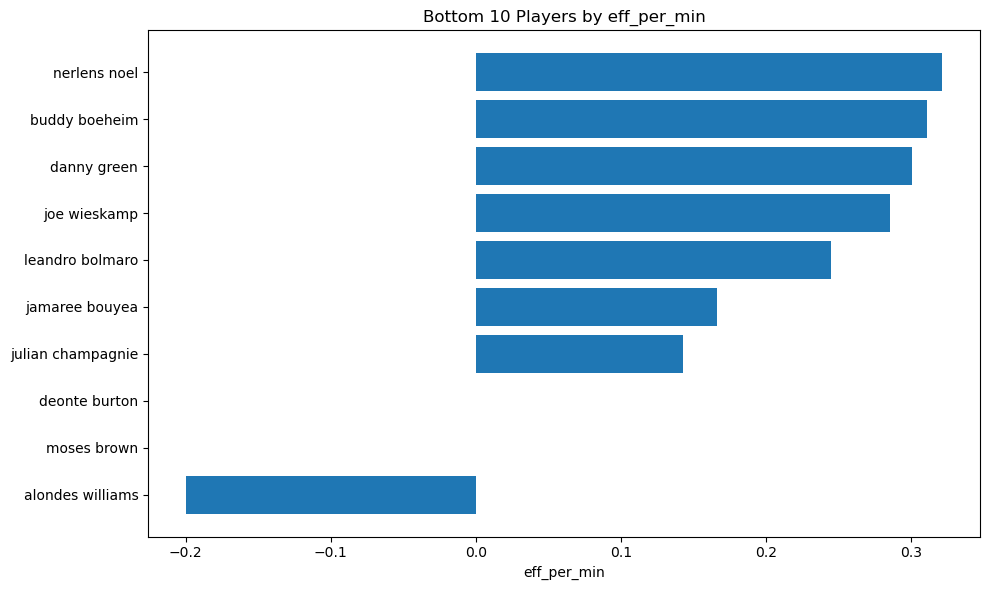

In [25]:
plots_dir = "plots"
os.makedirs(plots_dir, exist_ok=True)

top10_eff = df.sort_values("eff_per_min", ascending=False).head(10)
print(top10_eff[["player", "tm", "eff_per_min"]])

plt.figure(figsize=(10, 6))
plt.barh(top10_eff["player"], top10_eff["eff_per_min"])
plt.gca().invert_yaxis()
plt.xlabel("eff_per_min")
plt.title("Top 10 Players by eff_per_min")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "top10_eff_per_min.png"), dpi=300)
plt.show()

bottom10_eff = df.sort_values("eff_per_min", ascending=True).head(10)
print(bottom10_eff[["player", "tm", "eff_per_min"]])

plt.figure(figsize=(10, 6))
plt.barh(bottom10_eff["player"], bottom10_eff["eff_per_min"])
plt.xlabel("eff_per_min")
plt.title("Bottom 10 Players by eff_per_min")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "bottom10_eff_per_min.png"), dpi=300)
plt.show()